In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
df = pd.read_csv('social_media_addiction.csv')

In [8]:

features = [
    'Daily_Usage_Time_min',
    'Posts_Per_Day',
    'Likes_Received_Daily',
    'Messages_Sent_Daily',
    'Scroll_Rate_ppm',
    'Productivity_Loss_Score',
    'Mental_Health_Index',
    'FOMO_Score'
]

X = df[features]

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Clustering
kmeans = KMeans(n_clusters=3)
df['Cluster'] = kmeans.fit_predict(X_scaled)

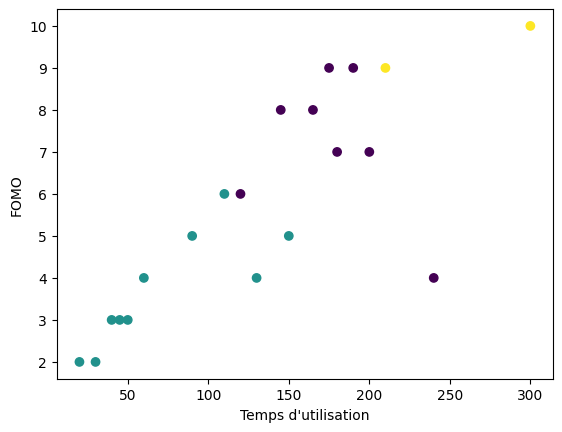

In [9]:
plt.scatter(df['Daily_Usage_Time_min'], df['FOMO_Score'], c=df['Cluster'])
plt.xlabel("Temps d'utilisation")
plt.ylabel("FOMO")
plt.show()

In [15]:
df['Cluster'] = (
    df['Cluster']
     .astype(int)
)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   User_ID                     20 non-null     int64
 1   Age                         20 non-null     int64
 2   Gender                      20 non-null     str  
 3   Platform                    20 non-null     str  
 4   Daily_Usage_Time_min        20 non-null     int64
 5   Posts_Per_Day               20 non-null     int64
 6   Likes_Received_Daily        20 non-null     int64
 7   Comments_Received_Daily     20 non-null     int64
 8   Messages_Sent_Daily         20 non-null     int64
 9   Scroll_Rate_ppm             20 non-null     int64
 10  Addiction_Level             20 non-null     str  
 11  Emotional_State_Post_Usage  20 non-null     str  
 12  Productivity_Loss_Score     20 non-null     int64
 13  Mental_Health_Index         20 non-null     int64
 14  FOMO_Score             

In [17]:
df

,User_ID,Age,Gender,Platform,Daily_Usage_Time_min,Posts_Per_Day,Likes_Received_Daily,Comments_Received_Daily,Messages_Sent_Daily,Scroll_Rate_ppm,Addiction_Level,Emotional_State_Post_Usage,Productivity_Loss_Score,Mental_Health_Index,FOMO_Score,Cluster
0,1001,23,Female,Instagram,145,3,120,25,45,40,High,Anxious,7,45,8,0
1,1002,19,Male,TikTok,210,1,45,5,10,85,Severe,Depressed,9,30,9,2
2,1003,28,Female,LinkedIn,45,0,5,2,15,10,Low,Motivated,2,80,3,1
3,1004,35,Male,Facebook,90,2,30,10,20,25,Moderate,Neutral,4,65,5,1
4,1005,21,Non-binary,Twitter,180,15,200,60,50,55,High,Stressed,8,40,7,0
5,1006,25,Male,YouTube,240,0,10,1,0,10,Severe,Bored,9,35,4,0
6,1007,31,Female,Instagram,60,1,50,8,30,20,Moderate,Happy,3,75,4,1
7,1008,22,Male,TikTok,165,5,90,12,35,70,High,Envious,6,50,8,0
8,1009,29,Female,Pinterest,30,0,2,0,5,15,Low,Inspired,1,85,2,1
9,1010,40,Male,Facebook,50,1,15,3,10,10,Low,Neutral,2,70,3,1


In [18]:
df['Cluster'].mean()

np.float64(0.7)

In [20]:
df.groupby('Cluster').mean(numeric_only=True)

,User_ID,Age,Daily_Usage_Time_min,Posts_Per_Day,Likes_Received_Daily,Comments_Received_Daily,Messages_Sent_Daily,Scroll_Rate_ppm,Productivity_Loss_Score,Mental_Health_Index,FOMO_Score
Cluster,,,,,,,,,,,
0,1010.125,22.0,176.875,6.625,91.875,23.75,90.625,42.5,7.25,43.125,7.25
1,1011.200,31.5,72.500,0.900,23.800,5.50,12.500,17.0,2.80,73.500,3.70
2,1008.500,19.5,255.000,2.500,62.500,17.50,25.000,90.0,9.50,27.500,9.50
